# Day 8 — Understanding the F1 Dataset

Load and inspect all F1 dataset files, document what each
represents, check data quality, and observe with a open questions.


## 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils import (
    load_all_csvs,
    profile_dataframe,
    summarize_all,
    missing_value_report,
    missing_value_report_all,
    duplicate_report,
    numeric_outlier_scan,
    check_referential_integrity,
)

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
sns.set_style("whitegrid")

DATA_DIR = "../dataset"


## 2. Load all dataset files

One function call loads everything into a dict of DataFrames, keyed by filename. This replaces 14 separate `pd.read_csv(...)` calls.

***Note***: the Ergast/F1 uses the string `\N` for SQL NULL — `load_all_csvs()` tells pandas to treat that as a missing value, so `.isna()` works correctly everywhere.

In [2]:
dfs = load_all_csvs(DATA_DIR)
print(f"Loaded {len(dfs)} files:")
for name in dfs:
    print(f"  - {name:25s} {dfs[name].shape}")


Loaded 14 files:
  - circuits                  (77, 9)
  - constructor_results       (12625, 5)
  - constructor_standings     (13391, 7)
  - constructors              (212, 5)
  - driver_standings          (34863, 7)
  - drivers                   (861, 9)
  - lap_times                 (589081, 6)
  - pit_stops                 (11371, 7)
  - qualifying                (10494, 9)
  - races                     (1125, 18)
  - results                   (26759, 18)
  - seasons                   (75, 2)
  - sprint_results            (360, 16)
  - status                    (139, 2)


## 3. What each file represents

| File | Each row represents | Key columns | Role |
|---|---|---|---|
| `seasons` | one F1 season | `year` | Reference — list of years |
| `races` | one Grand Prix event | `raceId`, `year`, `circuitId` | **Hub table** — almost everything joins through this |
| `circuits` | one track | `circuitId` | Reference — where races happen |
| `drivers` | one driver | `driverId` | Reference — who races |
| `constructors` | one team | `constructorId` | Reference — who they race for |
| `status` | one finish/DNF reason | `statusId` | Reference — lookup for `results.statusId` |
| `results` | one driver's result in one race | `raceId`+`driverId` | **Most important fact table** — final classification, points, time |
| `qualifying` | one driver's qualifying result | `raceId`+`driverId` | Q1/Q2/Q3 times, grid origin |
| `sprint_results` | one driver's sprint race result | `raceId`+`driverId` | Same shape as `results`, sprint format only (2021+) |
| `driver_standings` | a driver's cumulative points after a race | `raceId`+`driverId` | Championship standings snapshot |
| `constructor_standings` | a team's cumulative points after a race | `raceId`+`constructorId` | Championship standings snapshot |
| `constructor_results` | a team's points in one race | `raceId`+`constructorId` | Team-level points (pre-2010 had separate scoring) |
| `lap_times` | one driver's time on one lap | `raceId`+`driverId`+`lap` | **Largest file** — granular timing data |
| `pit_stops` | one pit stop event | `raceId`+`driverId`+`stop` | Pit lane timing |


## 4. Which files appear most important

Ranked by how central they are to answering typical F1 questions ("who won," "how did points develop," "who drove for whom"):

1. **`results`** — The most important fact table. Has the final classification, points, status, and timing for every driver in every race since 1950.
2. **`races`** — Needed to translate `raceId` into a year, round, and circuit for almost any other table.
3. **`drivers`** / **`constructors`** — Needed to turn IDs into names.
4. **`driver_standings`** / **`constructor_standings`** — Needed for answering the "championship at this point in the season" questions, which `results` alone cannot answer (it only has per-race points, not cumulative).
5. **`lap_times`** and **`pit_stops`** — Important for race-strategy / performance analysis, but not needed for season-level questions.
6. **`qualifying`**, **`sprint_results`**, **`constructor_results`** — Useful for specific questions (grid position, sprint) but not central to most analysis(supplemetary).
7. **`circuits`**, **`status`**, **`seasons`** — Small reference/lookup tables. Useful but low-stakes since they rarely have data quality issues at this size.


## 5. Data quality — summary across all 14 files

In [3]:
summary = summarize_all(dfs)
summary


,file,rows,columns,duplicate_rows,missing_cells,missing_%,cols_with_missing
0,lap_times,589081,6,0,0,0.00,0
1,driver_standings,34863,7,0,0,0.00,0
2,results,26759,18,0,122887,25.51,8
3,constructor_standings,13391,7,0,0,0.00,0
4,constructor_results,12625,5,0,12608,19.97,1
5,pit_stops,11371,7,0,0,0.00,0
6,qualifying,10494,9,0,11668,12.35,3
7,races,1125,18,0,11349,56.04,11
8,drivers,861,9,0,1559,20.12,2
9,sprint_results,360,16,0,73,1.27,5


**Observation:** no file has full-row duplicates. 

`races` has the highest missing-cell percentage (56%) but this is structural, not a data quality problem(see below).


### 5.1 Missing values — detail

In [33]:
missing_all = missing_value_report_all(dfs)
missing_all


/Users/phuwasinkriangdechachai/Desktop/Internship/utils.py:74: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  


,file,column,missing_count,missing_pct
0,constructor_results,status,12608,99.87
1,drivers,number,802,93.15
2,drivers,code,757,87.92
3,qualifying,q3,6865,65.42
4,qualifying,q2,4647,44.28
5,qualifying,q1,156,1.49
6,races,sprint_time,1110,98.67
7,races,sprint_date,1107,98.40
8,races,fp3_time,1072,95.29
9,races,fp1_time,1057,93.96


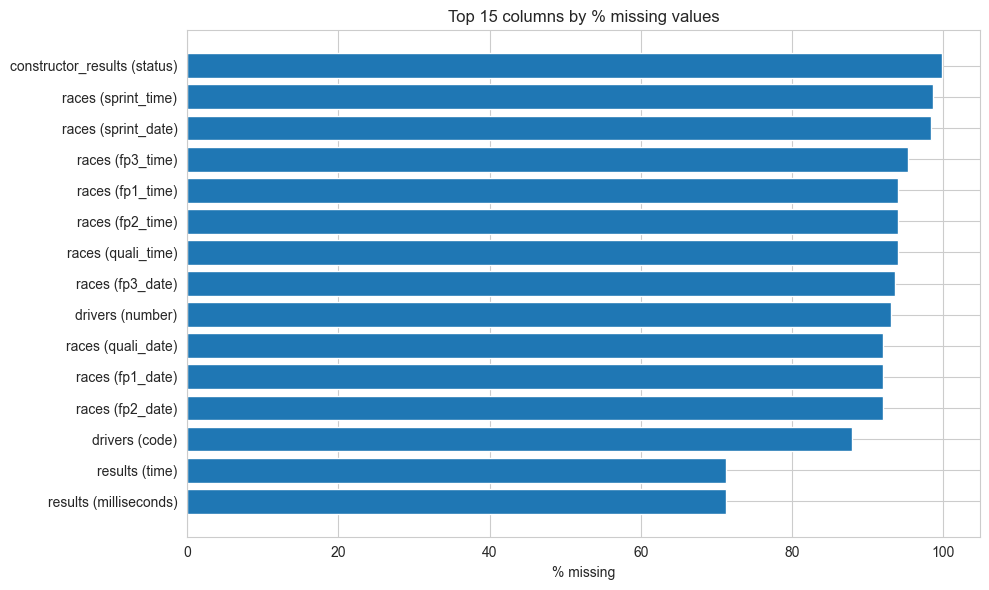

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))
top_missing = missing_all.sort_values("missing_pct", ascending=True).tail(15)
ax.barh(top_missing["file"] + " (" + top_missing["column"] + ")", top_missing["missing_pct"])
ax.set_xlabel("% missing")
ax.set_title("Top 15 columns by % missing values")

plt.tight_layout()
plt.savefig("missing_values_chart.png", dpi=120)
plt.show()


## Analysis
**Why `races` has so much missing data?:** the `fp1_date`, `fp1_time`, `fp2_*`, `fp3_*`, `quali_date/time`, and `sprint_date/time` columns are only populated from the 2021 season onward — every single race before 2021 has `NaN` in all of these columns, with no exceptions (verified below).

I've do some research about why — it's documented directly by Ergast, the organization that maintains this dataset. Their public changelog (http://ergast.com/mrd/category/news/) has two entries that explain exactly what happened:

1.  > **"Enhanced Schedule Data" — March 13, 2022**     
    > "This year the race schedule will include information about all the race sessions e.g. FP 1-3, qualifying and sprint races."

2.  > **"Sprint Qualifying Results" — March 3, 2022**  
    > "Sprint qualifying results will be properly supported during the 2022 season and data for the sprint races in 2021 has been added retrospectively."

In other words: Free Practice and Qualifying sessions obviously *happened* in every season back to 1950 — but Ergast only started **recording session date/time data** for them starting around the 2021 season. The missing values for 1950–2020 reflect a gap in what the data source chose to track, not a gap in F1 history itself.

Similarly, `drivers.number` and `drivers.code` are mostly missing for older drivers — permanent car numbers (`number`) were introduced as an official F1 rule starting in **2014** (also documented in the same Ergast changelog, "Permanent Driver Numbers," March 7, 2014), and 3-letter driver codes (`code`) follow the same modern-era convention.

For the `results`: ~25% missing across `time`, `milliseconds`, `fastestLap`, `rank`, `fastestLapTime`, `fastestLapSpeed`. This is mostly because a driver who didn't finish (DNF) or wasn't classified has no finish time or fastest-lap data to report — i.e. missingness correlates with `statusId != Finished`, which we verify below.


In [36]:
fp_cols = ["fp1_date", "fp2_date", "fp3_date", "quali_date", "sprint_date"]
races = dfs["races"]

for col in fp_cols:
    pre_2021 = races[races["year"] < 2021][col].notna().sum()
    post_2021 = races[races["year"] >= 2021][col].notna().sum()
    print(f"{col:15s} populated rows before 2021: {pre_2021:4d}   |   from 2021 onward: {post_2021:4d}")

fp1_date        populated rows before 2021:    0   |   from 2021 onward:   90
fp2_date        populated rows before 2021:    0   |   from 2021 onward:   90
fp3_date        populated rows before 2021:    0   |   from 2021 onward:   72
quali_date      populated rows before 2021:    0   |   from 2021 onward:   90
sprint_date     populated rows before 2021:    0   |   from 2021 onward:   18


In [34]:
results = dfs["results"]
status = dfs["status"]

merged = results.merge(status, on="statusId")
finished = merged[merged["status"] == "Finished"]
not_finished = merged[merged["status"] != "Finished"]

print("Missing 'time' when Finished:    ", finished["time"].isna().mean().round(3))
print("Missing 'time' when NOT Finished:", not_finished["time"].isna().mean().round(3))


Missing 'time' when Finished:     0.0
Missing 'time' when NOT Finished: 1.0


### 5.2 Duplicate records — exact and key-based

In [35]:
checks = [
    ("results", ["raceId", "driverId"]),
    ("qualifying", ["raceId", "driverId"]),
    ("driver_standings", ["raceId", "driverId"]),
    ("constructor_standings", ["raceId", "constructorId"]),
    ("pit_stops", ["raceId", "driverId", "stop"]),
    ("lap_times", ["raceId", "driverId", "lap"]),
    ("drivers", ["driverRef"]),
    ("constructors", ["constructorRef"]),
]

dup_results = [duplicate_report(dfs[name], name, keys) for name, keys in checks]
pd.DataFrame(dup_results)


,file,full_row_duplicates,key_columns,key_duplicates
0,results,0,"[raceId, driverId]",91
1,qualifying,0,"[raceId, driverId]",0
2,driver_standings,0,"[raceId, driverId]",0
3,constructor_standings,0,"[raceId, constructorId]",0
4,pit_stops,0,"[raceId, driverId, stop]",0
5,lap_times,0,"[raceId, driverId, lap]",0
6,drivers,0,[driverRef],0
7,constructors,0,[constructorRef],0


**Observation:** `results` has 91 rows where `(raceId, driverId)`repeats, every other table checked is fully clean on its key. This is the most concrete data quality finding in the dataset and is worth a closer look.
